/home/botian/miniconda3/envs/sim/lib/python3.7/site-packages/tqdm-4.64.1-py3.7.egg/tqdm/auto.py:22: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


(array([205., 173., 219., 209., 200., 207., 194., 189., 202., 202.]),
 array([1.0011624, 1.1010361, 1.2009099, 1.3007836, 1.4006573, 1.500531 ,
        1.6004047, 1.7002785, 1.8001522, 1.9000258, 1.9998996],
       dtype=float32),
 <BarContainer object of 10 artists>)

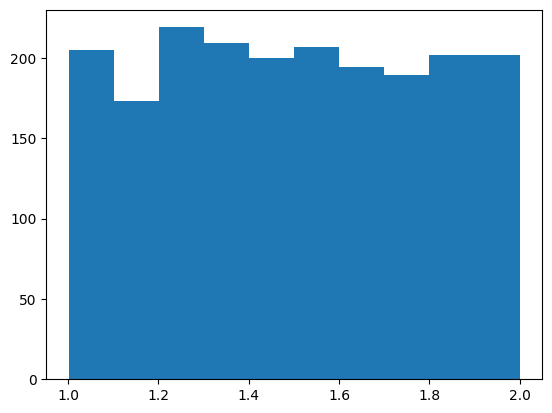

In [1]:
import torch
import torch.distributions as D
import matplotlib.pyplot as plt


def sample_uniform(size: torch.Size, low=0., high=1.):
    return (high - low) * torch.rand(size) + low

def sample_transformed(size: torch.Size, low=0., high=1., a=1.):
    return (high - low) * torch.rand(size) ** a + low
    
x = sample_uniform(2000, 1, 2)
plt.hist(x.numpy(), bins=10)

In [6]:
a = torch.arange(24).reshape(4, 2, 3)
i = torch.randint(0, 2, (4,))
a.take_along_dim(i.reshape(4, 1, 1), 1)

tensor([[[ 0,  1,  2]],

        [[ 9, 10, 11]],

        [[12, 13, 14]],

        [[21, 22, 23]]])

(array([643., 274., 191., 162., 148., 128., 122., 123., 107., 102.]),
 array([1.0000015, 1.0997686, 1.1995356, 1.2993026, 1.3990697, 1.4988368,
        1.5986037, 1.6983707, 1.7981378, 1.8979049, 1.9976718],
       dtype=float32),
 <BarContainer object of 10 artists>)

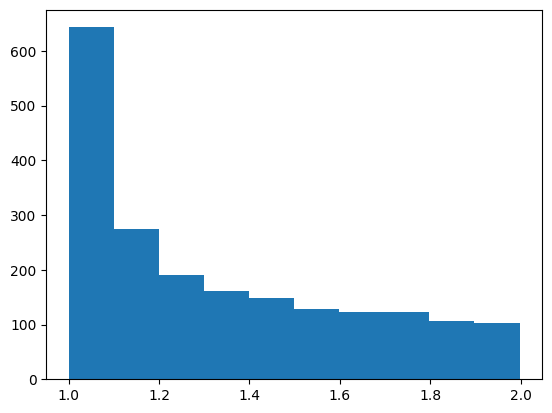

In [40]:
x = sample_transformed(2000, 1, 2, 2)
plt.hist(x.numpy(), bins=10)

(array([ 27.,  76., 100., 149., 167., 144., 133., 111.,  63.,  30.]),
 array([-0.9972977 , -0.79758424, -0.59787077, -0.39815727, -0.19844379,
         0.0012697 ,  0.20098318,  0.40069667,  0.60041016,  0.80012363,
         0.9998371 ], dtype=float32),
 <BarContainer object of 10 artists>)

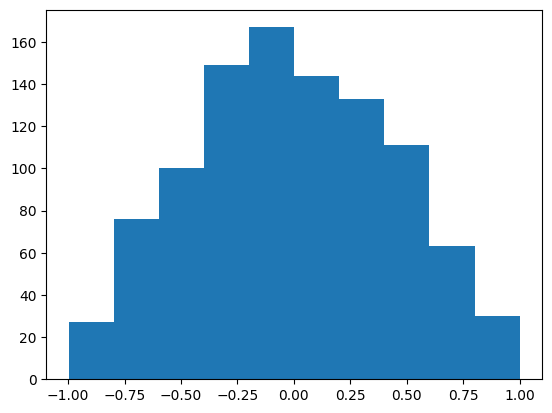

In [8]:
from torchrl.modules.distributions import TruncatedNormal

dist = TruncatedNormal(torch.zeros(1), torch.tensor(0.5), min=torch.tensor(-1), max=torch.tensor(1))
x = dist.sample((1000,))
plt.hist(x.numpy(), bins=10)